# Árbol de Decisión con Information Gain — Versión interactiva

Este notebook permite jugar con un árbol de decisión.

La idea es simple:

1. El usuario elige el **orden de las variables**.
2. El notebook construye un árbol siguiendo ese orden, aunque no sea el mejor.
3. El modelo hace predicciones.
4. Se muestra qué tan bien funcionó.
5. Luego se puede comparar contra un árbol **optimizado**, que elige automáticamente las mejores divisiones usando `Information Gain`.

El objetivo no es crear el modelo más avanzado, sino entender de forma visual cómo cambia el resultado cuando elegimos mal o bien las variables.

## 1. Cargar librerías

Usaremos librerías simples para leer datos, calcular métricas, crear gráficos y generar la interfaz interactiva.

In [1]:
# Cargar librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Librerías para dividir datos y evaluar modelos
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Librerías para la interfaz interactiva
import ipywidgets as widgets
from IPython.display import display, clear_output

# Configuración simple para ver mejor las tablas
pd.set_option('display.max_columns', None)

## 2. Leer archivo

El archivo debe estar en la misma carpeta que este notebook.

In [2]:
# Leer el dataset desde Excel
archivo = 'sample_decision_tree_dataset.xlsx'
df = pd.read_excel(archivo)

# Mostrar las primeras filas
df.head()

,Age,Income,Student,Credit_Rating,Buys_Product
0,Senior,High,No,Excellent,No
1,Youth,High,Yes,Excellent,Yes
2,Senior,High,No,Fair,No
3,Senior,Low,Yes,Excellent,Yes
4,Youth,High,No,Fair,No


## 3. Revisar el dataset

Este dataset tiene variables categóricas y una variable objetivo.

La última columna será tomada como la variable objetivo que queremos predecir.

In [3]:
# Ver tamaño del dataset
print('Filas y columnas:', df.shape)

# Ver nombres de columnas
print('Columnas:', list(df.columns))

# Ver valores faltantes
print('\nValores faltantes por columna:')
print(df.isnull().sum())

Filas y columnas: (100, 5)
Columnas: ['Age', 'Income', 'Student', 'Credit_Rating', 'Buys_Product']

Valores faltantes por columna:
Age              0
Income           0
Student          0
Credit_Rating    0
Buys_Product     0
dtype: int64


## 4. Definir variable objetivo y variables predictoras

En este ejemplo, la variable objetivo es la última columna del archivo.

In [4]:
# Definir variable objetivo como la última columna
target = df.columns[-1]

# Definir variables predictoras como todas las columnas menos la variable objetivo
features = [col for col in df.columns if col != target]

print('Variable objetivo:', target)
print('Variables predictoras:', features)

Variable objetivo: Buys_Product
Variables predictoras: ['Age', 'Income', 'Student', 'Credit_Rating']


## 5. Explicación simple: ¿qué es Entropía?

La **entropía** mide qué tan mezclados están los datos.

- Si todos los casos pertenecen a la misma clase, la entropía es **0**.
- Si las clases están muy mezcladas, la entropía es **más alta**.

Un árbol de decisión busca dividir los datos para que cada grupo quede lo más puro posible.

In [5]:
# Función para calcular entropía
def calcular_entropia(serie):
    proporciones = serie.value_counts(normalize=True)
    entropia = -np.sum(proporciones * np.log2(proporciones))
    return entropia

# Calcular entropía inicial de la variable objetivo
entropia_inicial = calcular_entropia(df[target])
print('Entropía inicial:', round(entropia_inicial, 4))

Entropía inicial: 0.9988


## 6. Explicación simple: ¿qué es Information Gain?

El **Information Gain** mide cuánto mejora una variable la separación de las clases.

La idea es:

```text
Information Gain = Entropía antes de dividir - Entropía después de dividir
```

Una variable con mayor Information Gain normalmente es una mejor primera pregunta para el árbol.

Ejemplo conceptual:

```text
¿Es estudiante?  → puede separar mejor a los compradores y no compradores
¿Tiene ingreso alto? → tal vez separa peor
```

El árbol optimizado intenta elegir la variable con mejor ganancia en cada paso.

In [6]:
# Función para calcular Information Gain de una variable
def calcular_information_gain(data, variable, objetivo):
    entropia_antes = calcular_entropia(data[objetivo])
    entropia_despues = 0

    for valor in data[variable].unique():
        subset = data[data[variable] == valor]
        peso = len(subset) / len(data)
        entropia_despues += peso * calcular_entropia(subset[objetivo])

    ganancia = entropia_antes - entropia_despues
    return ganancia

# Calcular Information Gain para cada variable en el dataset completo
ganancias = []
for variable in features:
    ganancias.append({
        'Variable': variable,
        'Information Gain': calcular_information_gain(df, variable, target)
    })

tabla_ganancias = pd.DataFrame(ganancias).sort_values(by='Information Gain', ascending=False)
tabla_ganancias

,Variable,Information Gain
0,Age,0.018983
2,Student,0.018229
3,Credit_Rating,0.009744
1,Income,0.002355


## 7. Dividir datos en Training y Testing

Para probar si el árbol realmente predice bien, usamos una parte para entrenar y otra parte para probar.

- **Training:** datos para aprender.
- **Testing:** datos nuevos para evaluar.

In [7]:
# Dividir datos originales para el árbol manual
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df[target]
)

print('Filas de entrenamiento:', train_df.shape[0])
print('Filas de prueba:', test_df.shape[0])

Filas de entrenamiento: 70
Filas de prueba: 30


## 8. Crear árbol manual siguiendo el orden elegido por el usuario

Este árbol NO decide automáticamente cuál variable usar.

El usuario elige el orden, por ejemplo:

```text
1. Income
2. Age
3. Student
4. Credit_Rating
```

El árbol va a seguir ese orden aunque no sea óptimo. Esto permite ver cómo una mala selección de variables puede bajar la calidad de las predicciones.

In [18]:
def clase_mayoritaria(y_target):
    # y_target is a Series of target values
    return y_target.mode()[0]

# Función para construir un árbol manual siguiendo un orden fijo de variables,
# pero realizando splits binarios en variables dummy para features categóricas.
def construir_arbol_manual(
    X_data, # X_data will be X_dummies (one-hot encoded features)
    y_target, # y_target will be the target series
    variables_ordenadas, # Original feature names in user-defined order
    features_map, # Dictionary to map original feature name to its dummy columns
    original_features # List of original feature names
):
    # Si todos los datos tienen la misma clase, se termina el árbol
    if y_target.nunique() == 1:
        return y_target.iloc[0]

    # Si no quedan variables originales por procesar o el subset está vacío
    if len(variables_ordenadas) == 0 or X_data.empty:
        return clase_mayoritaria(y_target)

    # Tomar la siguiente variable ORIGINAL según el orden elegido por el usuario
    original_feature = variables_ordenadas[0]

    # Identificar todas las columnas dummy asociadas con esta variable original
    dummy_cols_for_feature = [col for col in X_data.columns if col.startswith(f'{original_feature}_')]

    # If no dummy columns are found or all dummy columns have no variance in current subset,
    # move to the next original feature in the order
    if not dummy_cols_for_feature or all(X_data[col].nunique() == 1 for col in dummy_cols_for_feature):
        return construir_arbol_manual(
            X_data,
            y_target,
            variables_ordenadas[1:], # Pass remaining original features
            features_map,
            original_features
        )

    # Calculate Information Gain for each dummy column of the current original_feature
    best_dummy_feature = None
    max_ig = -1

    for dummy_col in dummy_cols_for_feature:
        # Ensure there's variance in the dummy column for IG calculation
        if X_data[dummy_col].nunique() > 1:
            # Need a temporary DataFrame for calcular_information_gain
            temp_df = X_data[[dummy_col]].copy()
            temp_df['target'] = y_target # Add target to calculate IG
            ig = calcular_information_gain(temp_df, dummy_col, 'target')
            if ig > max_ig:
                max_ig = ig
                best_dummy_feature = dummy_col

    # If no suitable dummy feature was found, use majority class
    if best_dummy_feature is None:
        return clase_mayoritaria(y_target)

    arbol = {
        'variable': best_dummy_feature, # Store the actual dummy feature name for splitting
        'mayoria': clase_mayoritaria(y_target),
        'ramas': {}
    }

    # Create branches for 0 and 1 values of the chosen dummy feature
    for valor in [0, 1]:
        subset_X = X_data[X_data[best_dummy_feature] == valor]
        subset_y = y_target[X_data[best_dummy_feature] == valor]

        if subset_X.empty:
            arbol['ramas'][valor] = clase_mayoritaria(y_target)
        else:
            # Pass remaining original features, excluding the one just processed
            arbol['ramas'][valor] = construir_arbol_manual(
                subset_X,
                subset_y,
                variables_ordenadas[1:], # Move to the next original feature in the user's order
                features_map,
                original_features
            )

    return arbol

# Función para predecir un registro usando el árbol manual (ahora con X_dummies)
def predecir_uno(arbol, fila_dummies):
    # Si el nodo es una clase final, devolver la clase
    if not isinstance(arbol, dict):
        return arbol

    variable_dummy = arbol['variable'] # This is now a dummy feature name

    # Check if the dummy feature exists in the input fila_dummies
    if variable_dummy not in fila_dummies.index:
        return arbol['mayoria'] # Fallback if feature is missing

    valor = fila_dummies[variable_dummy]

    # If the value (0 or 1) is not in the branches, use the majority class of the node
    if valor not in arbol['ramas']:
        return arbol['mayoria']

    return predecir_uno(arbol['ramas'][valor], fila_dummies)

# Función para predecir varios registros (ahora con X_dummies)
def predecir_varios(arbol, X_data_dummies):
    predicciones = []
    for _, fila in X_data_dummies.iterrows():
        predicciones.append(predecir_uno(arbol, fila))
    return predicciones

## 9. Dibujar el árbol manual

La siguiente función dibuja el árbol construido por el usuario.

Cada nodo muestra la variable usada para dividir. Cada hoja muestra la predicción final.

In [19]:
# Función auxiliar para contar hojas del árbol
def contar_hojas(arbol):
    if not isinstance(arbol, dict):
        return 1
    return sum(contar_hojas(rama) for rama in arbol['ramas'].values())

# Función auxiliar para calcular posiciones de los nodos
def asignar_posiciones(arbol, depth=0, x_counter=[0], posiciones=None, etiquetas=None, conexiones=None, edge_labels=None):
    if posiciones is None:
        posiciones = {}
        etiquetas = {}
        conexiones = []
        edge_labels = []

    node_id = len(posiciones)

    if not isinstance(arbol, dict):
        x = x_counter[0]
        x_counter[0] += 1
        posiciones[node_id] = (x, -depth)
        etiquetas[node_id] = 'Predicción:\n' + str(arbol)
        return node_id, posiciones, etiquetas, conexiones, edge_labels

    child_ids = []
    # The branches are now for values 0 and 1
    for valor in sorted(arbol['ramas'].keys()):
        rama = arbol['ramas'][valor]
        child_id, posiciones, etiquetas, conexiones, edge_labels = asignar_posiciones(
            rama, depth + 1, x_counter, posiciones, etiquetas, conexiones, edge_labels
        )
        child_ids.append(child_id)
        conexiones.append((node_id, child_id))

        # Label edges as value <= 0.5 or value > 0.5 (for 0/1 dummy features)
        if valor == 0:
            edge_label_text = f'<= 0.5'
        else:
            edge_label_text = f'> 0.5'
        edge_labels.append((node_id, child_id, edge_label_text))

    xs = [posiciones[c][0] for c in child_ids]
    x = np.mean(xs) if xs else x_counter[0]
    posiciones[node_id] = (x, -depth)

    # The variable is now a dummy feature name
    etiquetas[node_id] = f'Variable:\n{arbol["variable"]}'

    return node_id, posiciones, etiquetas, conexiones, edge_labels

# Función para dibujar el árbol manual
def dibujar_arbol_manual(arbol):
    fig, ax = plt.subplots(figsize=(18, 10)) # Increased figure size for better visibility

    x_counter = [0]
    _, posiciones, etiquetas, conexiones, edge_labels = asignar_posiciones(arbol, x_counter=x_counter)

    # Dibujar conexiones
    for origen, destino in conexiones:
        x1, y1 = posiciones[origen]
        x2, y2 = posiciones[destino]
        ax.plot([x1, x2], [y1, y2], '-k', lw=1)

    # Dibujar etiquetas de las ramas
    for origen, destino, texto in edge_labels:
        x1, y1 = posiciones[origen]
        x2, y2 = posiciones[destino]
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.05, texto, ha='center', va='bottom', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8))

    # Dibujar nodos
    for node_id, (x, y) in posiciones.items():
        ax.text(
            x, y, etiquetas[node_id],
            ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', fc='lightgray', ec='black', lw=0.5)
        )

    ax.axis('off')
    plt.title('Árbol manual creado con el orden elegido por el usuario (splits numéricos)')
    plt.tight_layout()
    plt.show()

## 10. Interfaz interactiva: elegir orden de variables

Use los menús desplegables para elegir el orden completo de las variables.

Luego presione:

- **Ejecutar árbol manual:** crea el árbol siguiendo su orden.
- **Ejecutar árbol optimizado:** deja que el algoritmo elija las mejores divisiones usando Information Gain.

La comparación permite ver que no cualquier orden genera buenas predicciones.

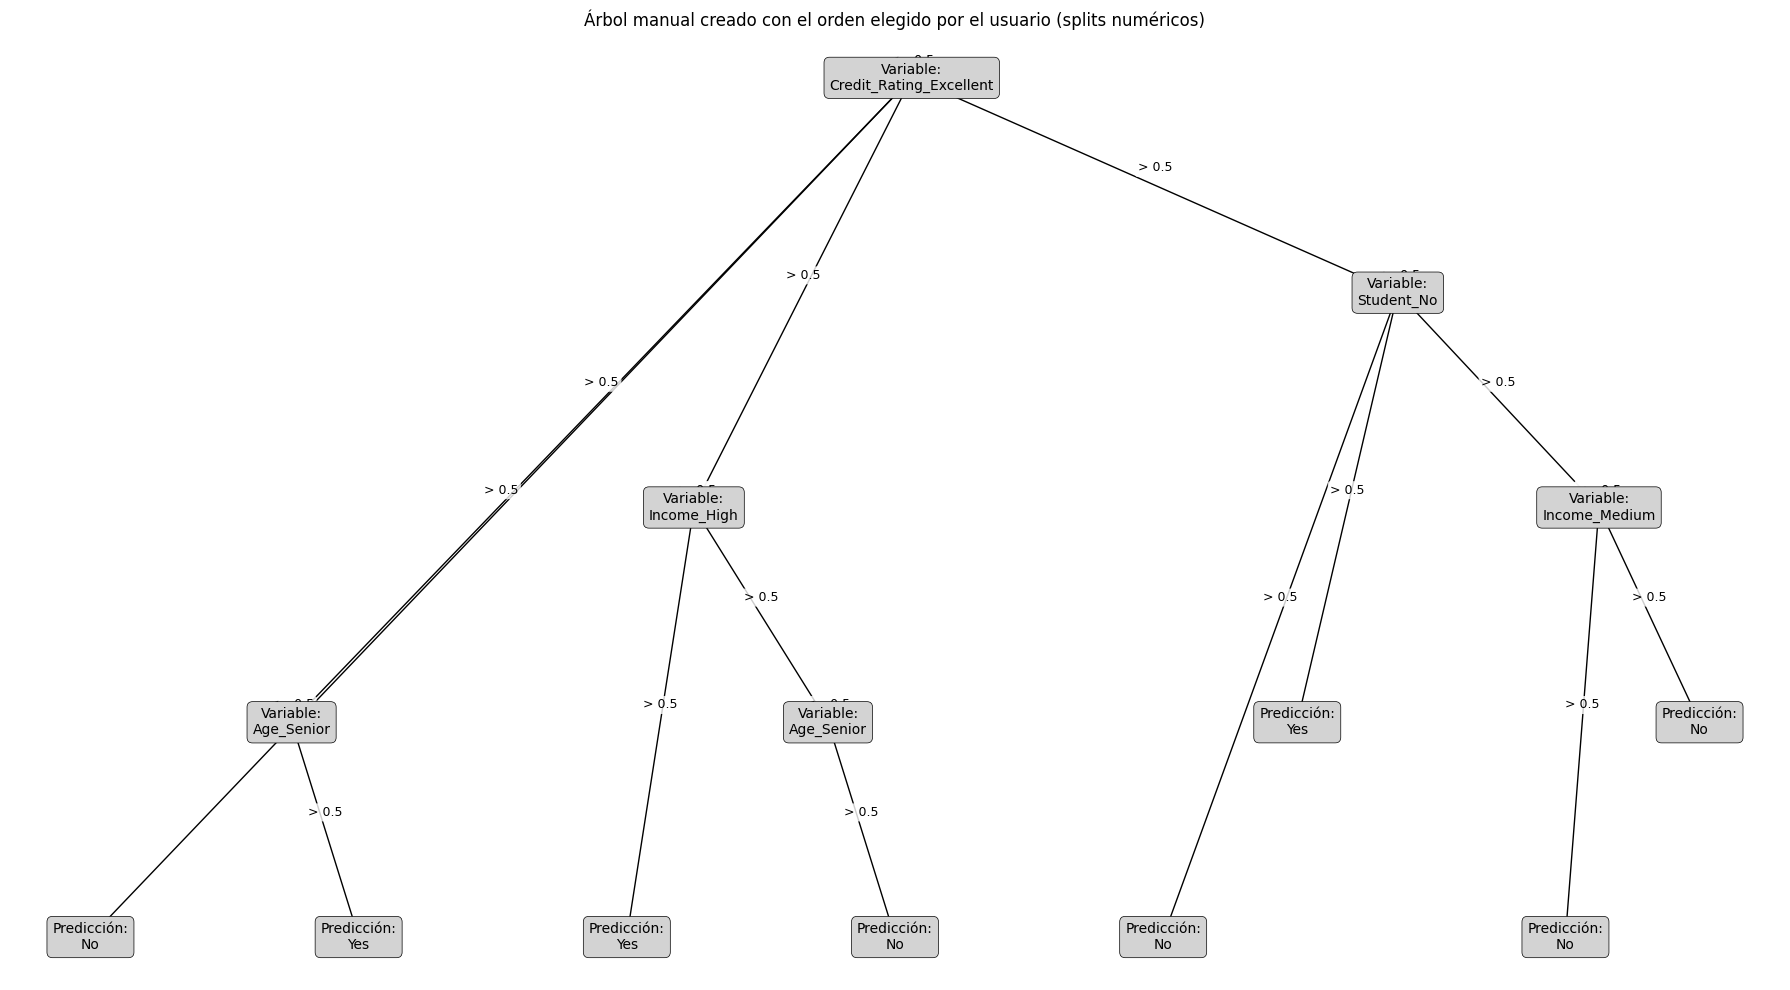

In [22]:
# Crear dropdowns para elegir el orden de las variables
orden_widgets = []

for i, variable in enumerate(features):
    dropdown = widgets.Dropdown(
        options=features,
        value=features[i],
        description=f'Posición {i+1}:',
        style={'description_width': '90px'},
        layout=widgets.Layout(width='350px')
    )
    orden_widgets.append(dropdown)

boton_manual = widgets.Button(
    description='Ejecutar árbol manual',
    button_style='info',
    icon='play'
)

boton_optimizado = widgets.Button(
    description='Ejecutar árbol optimizado',
    button_style='success',
    icon='check'
)

checkbox_visualizar = widgets.Checkbox(
    description='Visualizar árboles',
    value=True,  # Default to visualizing trees
    indent=False
)

salida = widgets.Output()

# Function to execute manual tree
def ejecutar_manual(b):
    with salida:
        clear_output()

        orden = [w.value for w in orden_widgets]

        # Validar que no haya variables repetidas
        if len(orden) != len(set(orden)):
            print('Error: no se pueden repetir variables.')
            print('Cada posición debe tener una variable diferente.')
            return

        print('ORDEN ELEGIDO POR EL USUARIO')
        for i, variable in enumerate(orden, start=1):
            print(f'{i}. {variable}')

        # Show initial Information Gain for reference
        print('\nINFORMATION GAIN EN EL NODO INICIAL (original features)')
        tabla = pd.DataFrame({
            'Variable': features,
            'Information Gain': [calcular_information_gain(train_df, v, target) for v in features]
        }).sort_values(by='Information Gain', ascending=False)
        display(tabla)

        print('\nNota: el árbol manual sigue el orden de *variables originales* elegido, pero realiza splits numéricos en las *variables dummy* más informativas dentro de cada variable original.')

        # Prepare one-hot encoded data for manual tree
        X_train_manual = train_df[features].copy()
        y_train_manual = train_df[target].copy()
        X_test_manual = test_df[features].copy()
        y_test_manual = test_df[target].copy()

        X_train_dummies_manual = pd.get_dummies(X_train_manual, drop_first=False)
        X_test_dummies_manual = pd.get_dummies(X_test_manual, drop_first=False)

        # Ensure test dummies have same columns as train dummies (important for prediction)
        X_test_dummies_manual = X_test_dummies_manual.reindex(columns=X_train_dummies_manual.columns, fill_value=0)

        # Build manual tree with dummy data
        arbol_manual = construir_arbol_manual(
            X_train_dummies_manual,
            y_train_manual,
            orden, # User's order of ORIGINAL features
            features, # Original features list for mapping
            features # Pass original features again for convenience if needed later
        )

        # Predict on testing data using dummy data
        y_pred = predecir_varios(arbol_manual, X_test_dummies_manual)

        # Calculate accuracy
        accuracy = accuracy_score(y_test_manual, y_pred)
        print('\nRESULTADO DEL ÁRBOL MANUAL')
        print('Accuracy:', round(accuracy, 4))
        print('\nReporte de clasificación:')
        print(classification_report(y_test_manual, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(y_test_manual, y_pred, labels=sorted(df[target].unique()))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(df[target].unique()))
        disp.plot()
        plt.title('Matriz de confusión - Árbol manual')
        plt.show()

        # Draw manual tree if checkbox is checked
        if checkbox_visualizar.value:
            dibujar_arbol_manual(arbol_manual)

# Function to execute optimized tree
def ejecutar_optimizado(b):
    with salida:
        clear_output()

        print('ÁRBOL OPTIMIZADO (usando nuestra función con orden óptimo)')
        print('Este árbol elige el orden de las variables originales según el Information Gain más alto.')

        # Determine optimal order of original features based on Information Gain
        ig_scores = []
        for variable in features:
            ig_scores.append({
                'Variable': variable,
                'Information Gain': calcular_information_gain(train_df, variable, target)
            })
        optimal_order_df = pd.DataFrame(ig_scores).sort_values(by='Information Gain', ascending=False)
        optimal_order = optimal_order_df['Variable'].tolist()

        print('\nORDEN DE VARIABLES OPTIMIZADO (por Information Gain):')
        for i, variable in enumerate(optimal_order, start=1):
            print(f'{i}. {variable}')
        display(optimal_order_df)

        print('\nNota: el árbol optimizado calcula el orden de *variables originales* según IG, y luego realiza splits numéricos en las *variables dummy* más informativas dentro de cada variable original.')

        # Prepare one-hot encoded data for optimized tree
        X_train_optim = train_df[features].copy()
        y_train_optim = train_df[target].copy()
        X_test_optim = test_df[features].copy()
        y_test_optim = test_df[target].copy()

        X_train_dummies_optim = pd.get_dummies(X_train_optim, drop_first=False)
        X_test_dummies_optim = pd.get_dummies(X_test_optim, drop_first=False)

        # Ensure test dummies have same columns as train dummies
        X_test_dummies_optim = X_test_dummies_optim.reindex(columns=X_train_dummies_optim.columns, fill_value=0)

        # Build optimized tree using our custom function and optimal order
        arbol_optimizado = construir_arbol_manual(
            X_train_dummies_optim,
            y_train_optim,
            optimal_order, # Pass the optimal order of ORIGINAL features
            features,
            features
        )

        # Predict on testing data using dummy data
        y_pred = predecir_varios(arbol_optimizado, X_test_dummies_optim)

        # Calculate accuracy
        accuracy = accuracy_score(y_test_optim, y_pred)
        print('\nRESULTADO DEL ÁRBOL OPTIMIZADO')
        print('Accuracy:', round(accuracy, 4))
        print('\nReporte de clasificación:')
        print(classification_report(y_test_optim, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(y_test_optim, y_pred, labels=sorted(df[target].unique()))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(df[target].unique()))
        disp.plot()
        plt.title('Matriz de confusión - Árbol optimizado')
        plt.show()

        # Draw optimized tree if checkbox is checked
        if checkbox_visualizar.value:
            dibujar_arbol_manual(arbol_optimizado)

boton_manual.on_click(ejecutar_manual)
boton_optimizado.on_click(ejecutar_optimizado)

# Display interface
interfaz_con_switch = widgets.VBox([
    widgets.HTML('<h3>Juego: elige el orden de las variables del árbol</h3>'),
    widgets.HTML('<p>Elige cada variable una sola vez. Luego ejecuta el árbol manual o el optimizado.</p>'),
    widgets.HBox(orden_widgets[:2]),
    widgets.HBox(orden_widgets[2:]),
    widgets.HBox([boton_manual, boton_optimizado]),
    checkbox_visualizar, # Add the new checkbox here
    salida
])

display(interfaz_con_switch)

In [17]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd
import numpy as np

# Re-initialize variables that might be needed if kernel state isn't fully preserved or for clarity
# Assuming 'features', 'target', 'df' (and its derivatives like train_df, test_df) are globally available from previous cells).
# If not, they would need to be re-defined or passed. For this scenario, I assume they are in scope.

# Create dropdowns for choosing the order of variables (re-creating them)
orden_widgets = []

for i, variable in enumerate(features):
    dropdown = widgets.Dropdown(
        options=features,
        value=features[i],
        description=f'Posición {i+1}:',
        style={'description_width': '90px'},
        layout=widgets.Layout(width='350px')
    )
    orden_widgets.append(dropdown)

boton_manual = widgets.Button(
    description='Ejecutar árbol manual',
    button_style='info',
    icon='play'
)

boton_optimizado = widgets.Button(
    description='Ejecutar árbol optimizado',
    button_style='success',
    icon='check'
)

checkbox_visualizar = widgets.Checkbox(
    description='Visualizar árboles',
    value=True,  # Default to visualizing trees
    indent=False
)

salida = widgets.Output()

# Function to execute manual tree
def ejecutar_manual(b):
    with salida:
        clear_output()

        orden = [w.value for w in orden_widgets]

        # Validate that there are no repeated variables
        if len(orden) != len(set(orden)):
            print('Error: no se pueden repetir variables.')
            print('Cada posición debe tener una variable diferente.')
            return

        print('ORDEN ELEGIDO POR EL USUARIO')
        for i, variable in enumerate(orden, start=1):
            print(f'{i}. {variable}')

        # Show initial Information Gain for reference
        print('INFORMATION GAIN EN EL NODO INICIAL')
        tabla = pd.DataFrame({
            'Variable': features,
            'Information Gain': [calcular_information_gain(train_df, v, target) for v in features]
        }).sort_values(by='Information Gain', ascending=False)
        display(tabla)

        print('\nNota: el árbol manual sigue el orden elegido, aunque otra variable tenga mayor Information Gain.')

        # Build manual tree
        arbol_manual = construir_arbol_manual(train_df, orden, target)

        # Predict on testing data
        y_test = test_df[target]
        y_pred = predecir_varios(arbol_manual, test_df)

        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        print('\nRESULTADO DEL ÁRBOL MANUAL')
        print('Accuracy:', round(accuracy, 4))
        print('\nReporte de clasificación:')
        print(classification_report(y_test, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred, labels=sorted(df[target].unique()))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(df[target].unique()))
        disp.plot()
        plt.title('Matriz de confusión - Árbol manual')
        plt.show()

        # Simple accuracy plot (ALWAYS SHOW) - User asked to remove this specific plot.
        # plt.figure(figsize=(5, 4))
        # plt.bar(['Árbol manual'], [accuracy])
        # plt.ylim(0, 1)
        # plt.ylabel('Accuracy')
        # plt.title('Calidad del árbol manual')
        # plt.show()

        # Draw manual tree if checkbox is checked
        if checkbox_visualizar.value:
            dibujar_arbol_manual(arbol_manual)

# Function to execute optimized tree
def ejecutar_optimizado(b):
    with salida:
        clear_output()

        print('ÁRBOL OPTIMIZADO')
        print('Este árbol elige automáticamente las mejores divisiones usando criterio de entropía.')

        # Show initial Information Gain for reference (added as per user request)
        print('\nINFORMATION GAIN EN EL NODO INICIAL')
        tabla_opt = pd.DataFrame({
            'Variable': features,
            'Information Gain': [calcular_information_gain(train_df, v, target) for v in features]
        }).sort_values(by='Information Gain', ascending=False)
        display(tabla_opt)

        # Create dummy variables for sklearn (re-doing split for consistency)
        X = df[features]
        y = df[target]
        X_dummies = pd.get_dummies(X, drop_first=False)

        X_train, X_test, y_train, y_test = train_test_split(
            X_dummies,
            y,
            test_size=0.30,
            random_state=42,
            stratify=y
        )

        # Create optimized model using entropy
        modelo = DecisionTreeClassifier(
            criterion='entropy',
            random_state=42,
            max_depth=None
        )

        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        print('\nRESULTADO DEL ÁRBOL OPTIMIZADO')
        print('Accuracy:', round(accuracy, 4))
        print('\nReporte de clasificación:')
        print(classification_report(y_test, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred, labels=sorted(df[target].unique()))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(df[target].unique()))
        disp.plot()
        plt.title('Matriz de confusión - Árbol optimizado')
        plt.show()

        # Importance of dummy variables
        importancias = pd.DataFrame({
            'Variable dummy': X_dummies.columns,
            'Importancia': modelo.feature_importances_
        }).sort_values(by='Importancia', ascending=False)

        print('\nVariables más importantes en el árbol optimizado:')
        display(importancias[importancias['Importancia'] > 0])

        print('\nORDEN DE VARIABLES EN EL ÁRBOL OPTIMIZADO (por importancia):')
        for i, (var, imp) in enumerate(importancias[importancias['Importancia'] > 0].iterrows()):
            print(f'{i+1}. {imp["Variable dummy"]} (Importancia: {imp["Importancia"]:.4f})')

        # Draw optimized tree if checkbox is checked
        if checkbox_visualizar.value:
            plt.figure(figsize=(18, 8))
            plot_tree(
                modelo,
                feature_names=X_dummies.columns,
                class_names=[str(c) for c in modelo.classes_],
                filled=False,
                rounded=True,
                fontsize=8
            )
            plt.title('Árbol optimizado con sklearn')
            plt.show()

boton_manual.on_click(ejecutar_manual)
boton_optimizado.on_click(ejecutar_optimizado)

# Display interface (redefining it)
interfaz_con_switch = widgets.VBox([
    widgets.HTML('<h3>Juego: elige el orden de las variables del árbol</h3>'),
    widgets.HTML('<p>Elige cada variable una sola vez. Luego ejecuta el árbol manual o el optimizado.</p>'),
    widgets.HBox(orden_widgets[:2]),
    widgets.HBox(orden_widgets[2:]),
    widgets.HBox([boton_manual, boton_optimizado]),
    checkbox_visualizar, # Add the new checkbox here
    salida
])

display(interfaz_con_switch)

## 11. Cómo interpretar el juego

Cuando el usuario cambia el orden de las variables, está cambiando las preguntas que el árbol hace primero.

Por ejemplo:

```text
Orden A:
1. Student
2. Credit_Rating
3. Income
4. Age
```

puede funcionar mejor que:

```text
Orden B:
1. Age
2. Income
3. Credit_Rating
4. Student
```

¿Por qué?

Porque algunas variables separan mejor las clases desde el inicio. Eso se mide con **Information Gain**.

El árbol optimizado hace esto automáticamente:

1. Calcula la ganancia de información.
2. Elige la mejor variable.
3. Repite el proceso dentro de cada rama.

El juego muestra que un árbol puede tener la misma información disponible, pero dar peores predicciones si usa las variables en un orden poco conveniente.

## 12. Conclusión simple

Un árbol de decisión se parece a un juego de preguntas.

Cada pregunta divide los datos en grupos. Si la pregunta es buena, los grupos quedan más claros. Si la pregunta es mala, el árbol puede confundirse.

**Information Gain** ayuda a elegir mejores preguntas.

Por eso, el árbol optimizado suele superar al árbol manual cuando el usuario elige un orden de variables poco adecuado.